In [2]:
from google.colab import files

uploaded = files.upload()

Saving placement_clustering.py to placement_clustering (1).py


In [3]:
from google.colab import files

uploaded = files.upload()

Saving placement_predict_50k_adjusted (1).....csv to placement_predict_50k_adjusted (1).....csv


In [4]:
import os

os.listdir('/content')

['.config',
 'placement_clustering (1).py',
 'placement_predict_50k_adjusted (1).....csv',
 'placement_clustering.py',
 'sample_data']

In [5]:
!pip install -q numpy pandas matplotlib scikit-learn scipy

In [6]:
!sed -i 's|placement_predict_50k_adjusted (1)|placement_predict_50k_adjusted (1).....csv|' placement_clustering.py

In [7]:
%run placement_clustering.py

PLACEMENTPREDICT STUDENT CLUSTERING: K-Means / Hierarchical / DBSCAN
Loaded 50,000 students, 33 clustering features (PlacementStatus & IsAnomaly excluded)
Saved plot -> kmeans_elbow_silhouette.png
Silhouette-suggested k = 2  (scores: k=2:0.144, k=3:0.078, k=4:0.073, k=5:0.053, k=6:0.081, k=7:0.095, k=8:0.102)

K-Means (k=2) silhouette (5k sample): 0.144
Cluster sizes: {0: 26429, 1: 23571}

--- Cluster profiles (KMeansCluster) ---
               n_students  placement_rate  avg_CGPA  avg_AttendancePercent  avg_AptitudeTestScore  avg_SoftSkillsRating  avg_CodingTestScore  avg_MockInterviewScore  avg_Internships  avg_Projects
KMeansCluster                                                                                                                                                                                      
0                   26429           0.202     6.558                 67.338                 54.559                 5.444               47.260                  54.743          

In [8]:
import os

files = [
    "kmeans_elbow_silhouette.png",
    "kmeans_pca.png",
    "hierarchical_dbscan_pca.png",
    "dendrogram.png",
    "cluster_profiles.csv",
    "placement_predict_with_clusters.csv"
]

for f in files:
    print("✅" if os.path.exists(f) else "❌", f)

✅ kmeans_elbow_silhouette.png
✅ kmeans_pca.png
✅ hierarchical_dbscan_pca.png
✅ dendrogram.png
✅ cluster_profiles.csv
✅ placement_predict_with_clusters.csv


In [9]:
import pandas as pd

cluster_profiles = pd.read_csv("cluster_profiles.csv")

cluster_profiles

,KMeansCluster,n_students,placement_rate,avg_CGPA,avg_AttendancePercent,avg_AptitudeTestScore,avg_SoftSkillsRating,avg_CodingTestScore,avg_MockInterviewScore,avg_Internships,avg_Projects
0,0,26429,0.202,6.558,67.338,54.559,5.444,47.260,54.743,0.621,1.556
1,1,23571,0.781,8.131,83.340,76.411,7.658,74.035,76.239,1.978,3.628


In [10]:
final_data = pd.read_csv("placement_predict_with_clusters.csv")

print("Rows:", len(final_data))
print("Columns:", len(final_data.columns))

final_data.head()

Rows: 50000
Columns: 22


,Gender,City,CollegeTier,Stream,Specialisation,Hostel,HistoryOfBacklogs,CGPA,AttendancePercent,Internships,...,Certifications,Publications,AptitudeTestScore,SoftSkillsRating,CodingTestScore,MockInterviewScore,ExtraCurricular,PlacementStatus,IsAnomaly,KMeansCluster
0,Female,Delhi,Tier3,IT,DataScience,Yes,Yes,6.63,68.3,2,...,1,0,62.3,6.57,40.6,65.7,No,0,0,0
1,Male,Chennai,Tier2,ECE,AI,Yes,No,6.40,71.0,1,...,2,0,44.0,5.86,40.3,51.8,No,0,0,0
2,Female,Hyderabad,Tier3,ECE,Networking,No,No,7.73,75.1,1,...,2,1,73.8,7.50,73.6,67.9,No,1,0,1
3,Female,Jaipur,Tier3,ECE,Embedded,No,No,9.73,99.2,4,...,6,2,100.0,9.41,98.7,NaN,No,1,0,1
4,Male,Ahmedabad,Tier3,Mechanical,DataScience,No,No,9.01,99.6,2,...,4,2,90.8,9.24,83.1,100.0,No,1,0,1


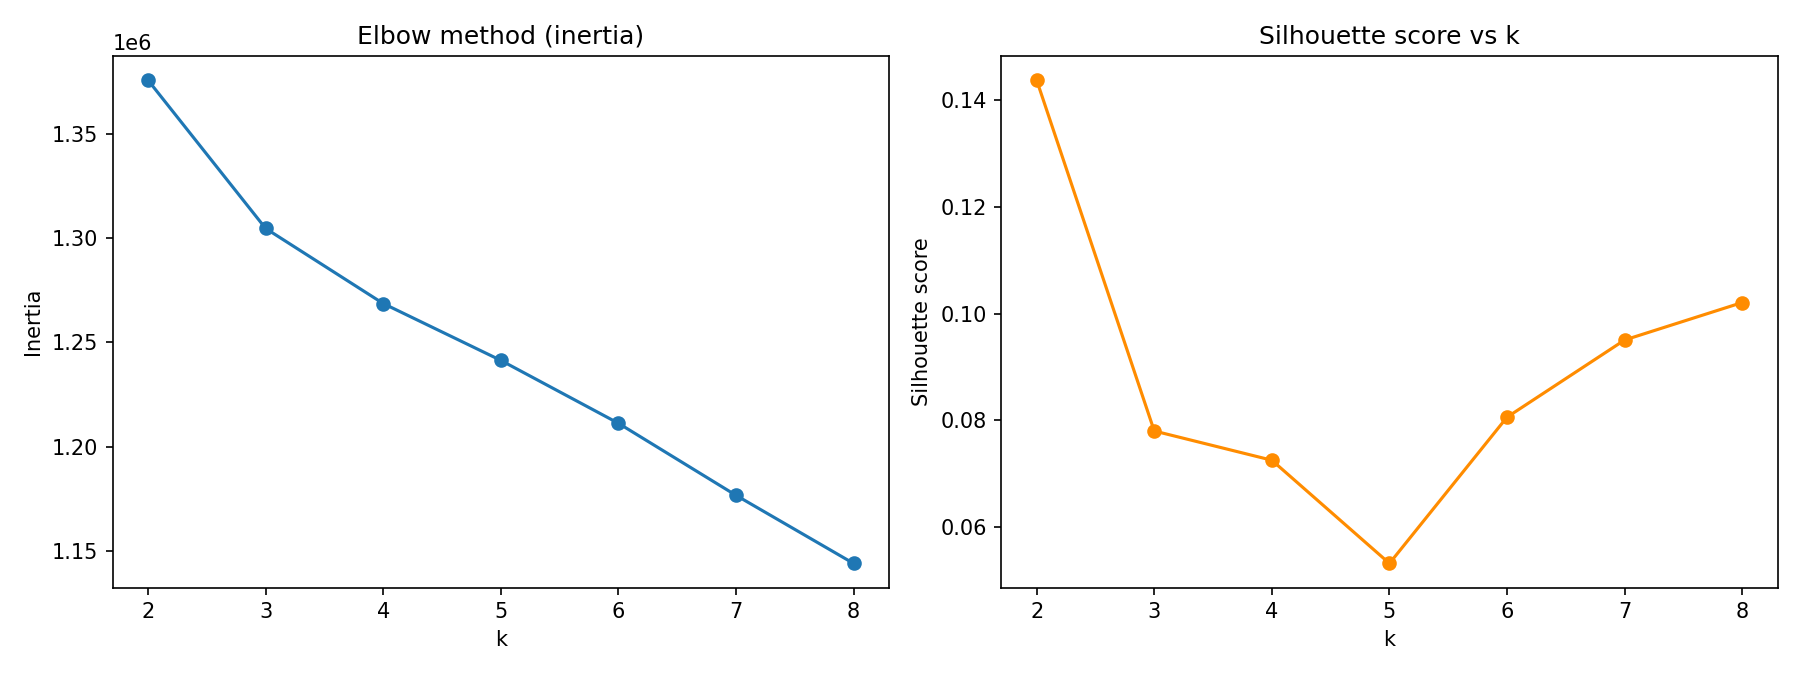

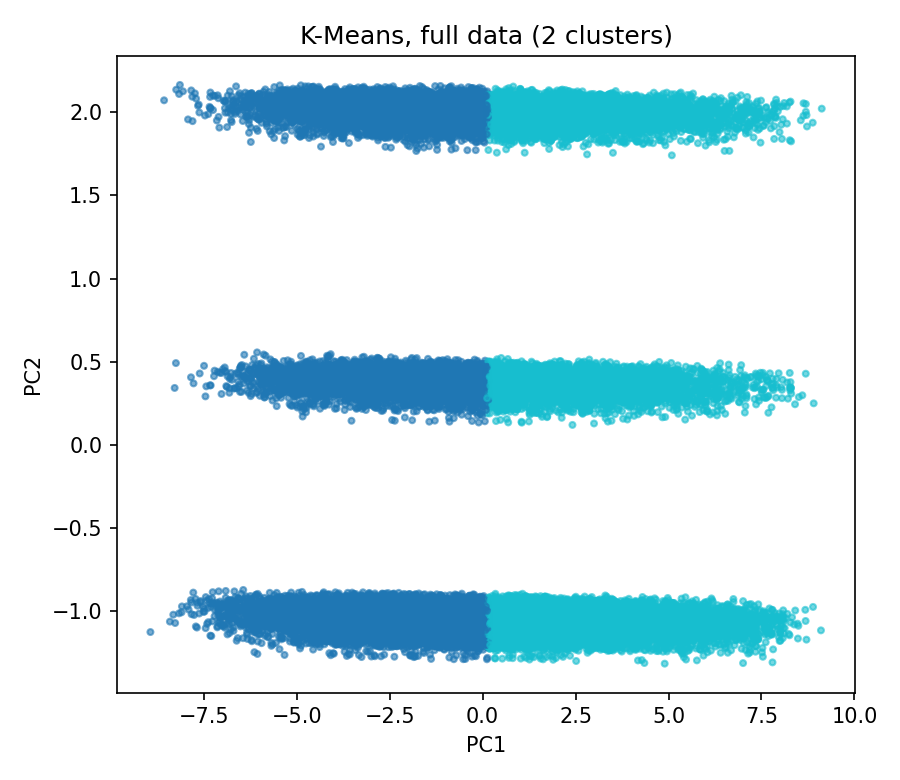

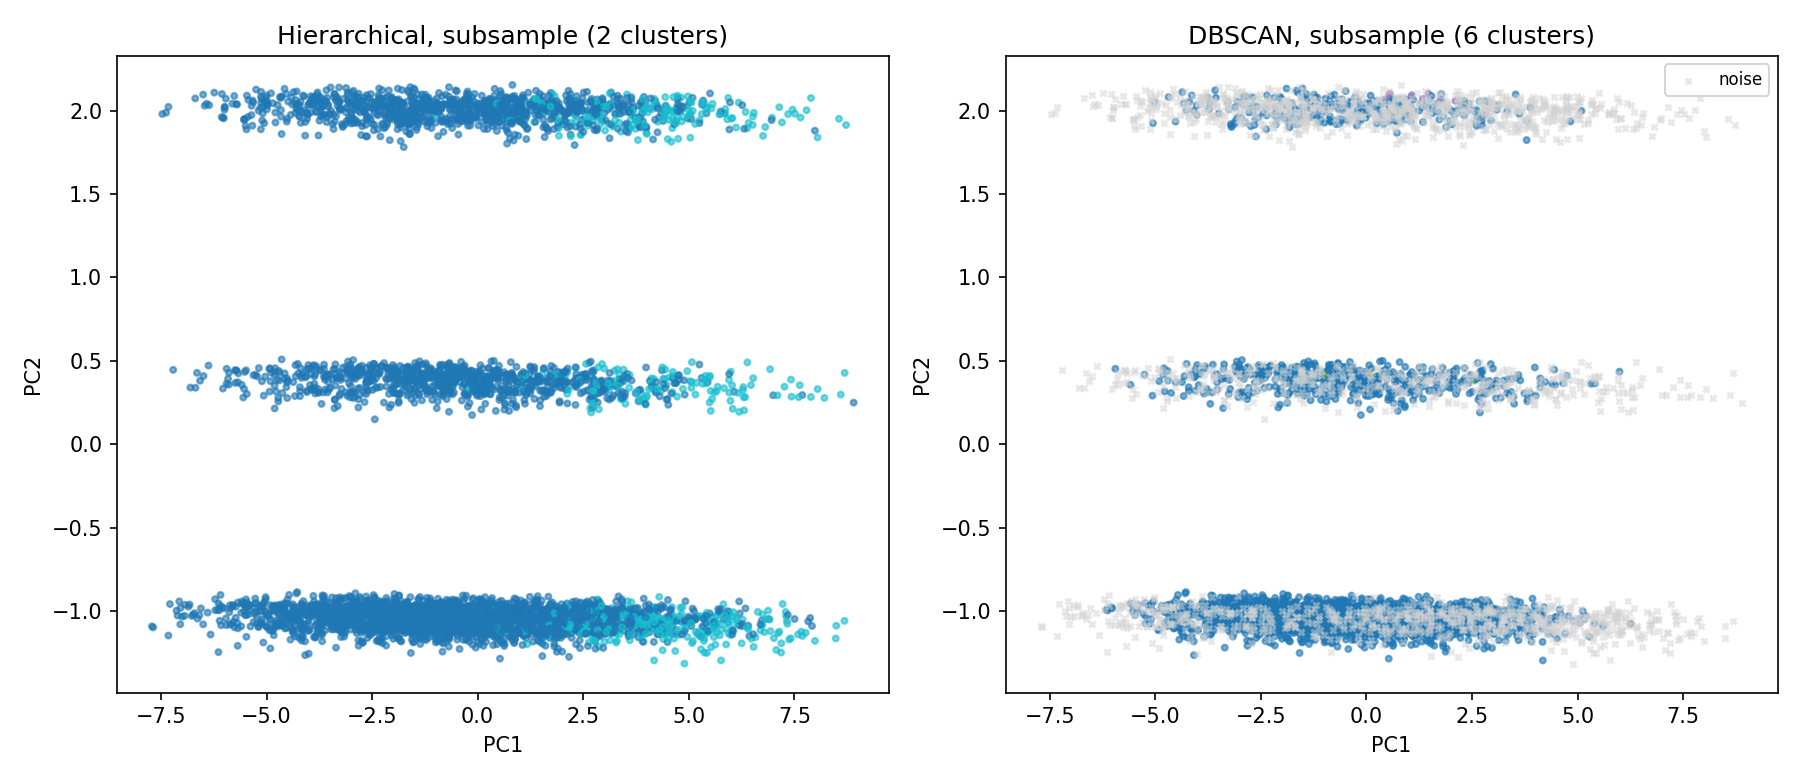

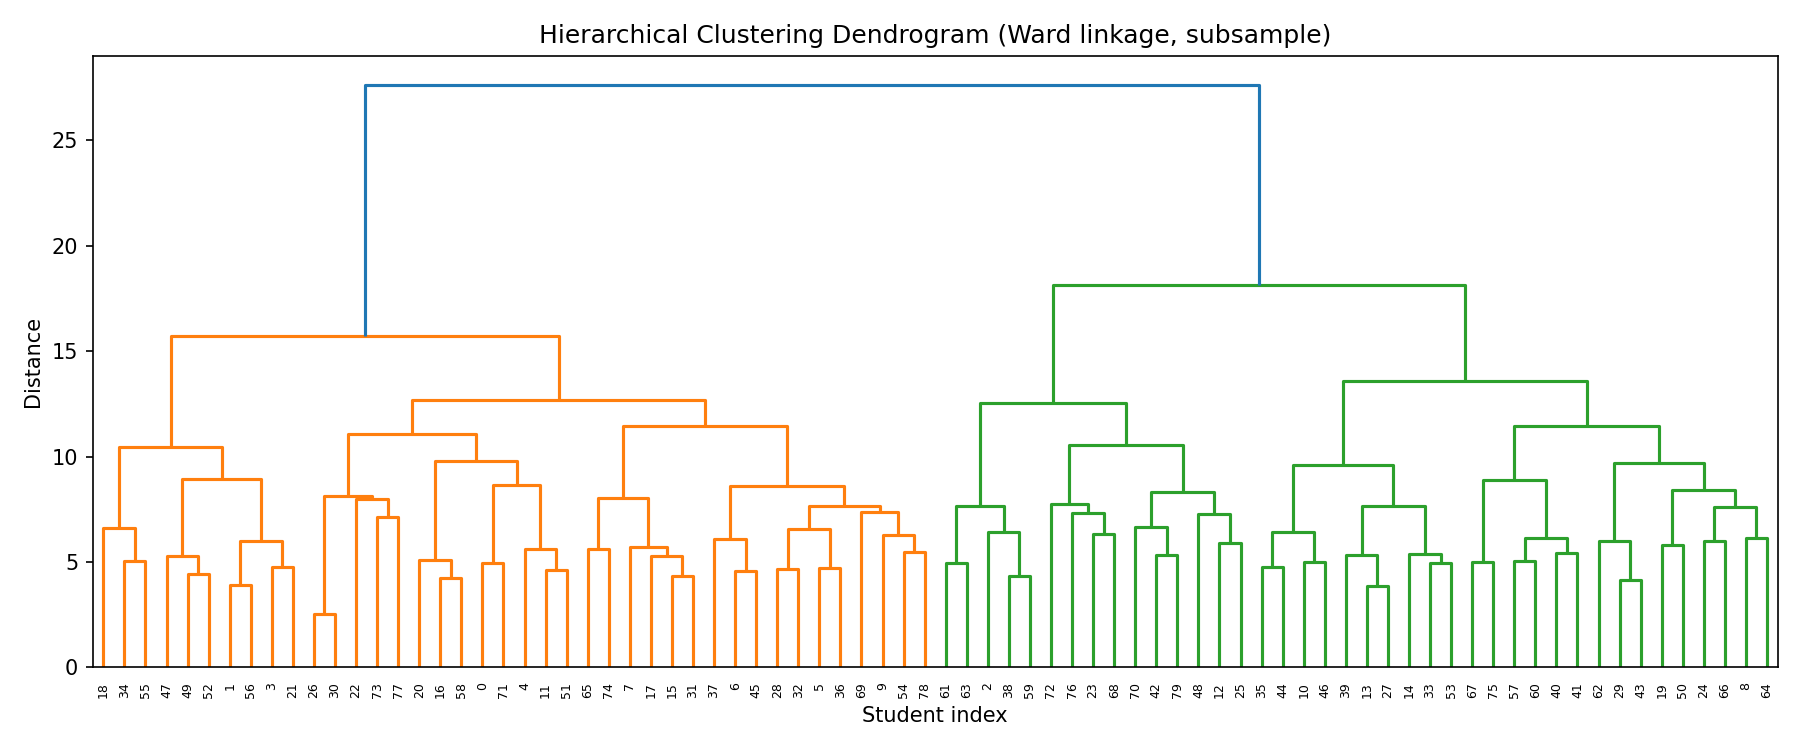

In [12]:
from IPython.display import Image, display

display(Image("kmeans_elbow_silhouette.png"))
display(Image("kmeans_pca.png"))
display(Image("hierarchical_dbscan_pca.png"))
display(Image("dendrogram.png"))

In [13]:
from google.colab import files

files.download("cluster_profiles.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [14]:
files.download("placement_predict_with_clusters.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [15]:
files.download("kmeans_elbow_silhouette.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [16]:
files.download("kmeans_pca.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [17]:
files.download("hierarchical_dbscan_pca.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [18]:
files.download("dendrogram.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [19]:
print("===== CLUSTER PROFILES =====")
display(cluster_profiles)

print("\n===== DATASET INFO =====")
print("Students:", len(final_data))
print("Columns:", len(final_data.columns))

print("\n===== K-MEANS CLUSTER COUNTS =====")
print(final_data["KMeansCluster"].value_counts().sort_index())

===== CLUSTER PROFILES =====


,KMeansCluster,n_students,placement_rate,avg_CGPA,avg_AttendancePercent,avg_AptitudeTestScore,avg_SoftSkillsRating,avg_CodingTestScore,avg_MockInterviewScore,avg_Internships,avg_Projects
0,0,26429,0.202,6.558,67.338,54.559,5.444,47.260,54.743,0.621,1.556
1,1,23571,0.781,8.131,83.340,76.411,7.658,74.035,76.239,1.978,3.628



===== DATASET INFO =====
Students: 50000
Columns: 22

===== K-MEANS CLUSTER COUNTS =====
KMeansCluster
0    26429
1    23571
Name: count, dtype: int64


In [20]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

print("===== COMPLETE CLUSTER PROFILE =====")
display(cluster_profiles)

===== COMPLETE CLUSTER PROFILE =====


,KMeansCluster,n_students,placement_rate,avg_CGPA,avg_AttendancePercent,avg_AptitudeTestScore,avg_SoftSkillsRating,avg_CodingTestScore,avg_MockInterviewScore,avg_Internships,avg_Projects
0,0,26429,0.202,6.558,67.338,54.559,5.444,47.260,54.743,0.621,1.556
1,1,23571,0.781,8.131,83.340,76.411,7.658,74.035,76.239,1.978,3.628


In [21]:
print("===== K-MEANS RESULTS =====")

print("Number of clusters:", final_data["KMeansCluster"].nunique())

print("\nCluster sizes:")
print(final_data["KMeansCluster"].value_counts().sort_index())

print("\nPlacement rates:")
display(
    final_data.groupby("KMeansCluster")["PlacementStatus"]
    .mean()
    .mul(100)
    .round(2)
)

===== K-MEANS RESULTS =====
Number of clusters: 2

Cluster sizes:
KMeansCluster
0    26429
1    23571
Name: count, dtype: int64

Placement rates:


,PlacementStatus
KMeansCluster,
0,20.16
1,78.15


In [22]:
print("===== ALGORITHM COMPARISON =====")

# K-Means
print("K-Means: completed on full dataset")

# Hierarchical and DBSCAN were run on 5000 samples
print("Hierarchical Clustering: completed on 5000-sample subset")
print("DBSCAN: completed on 5000-sample subset")

===== ALGORITHM COMPARISON =====
K-Means: completed on full dataset
Hierarchical Clustering: completed on 5000-sample subset
DBSCAN: completed on 5000-sample subset


In [23]:
import os

print("===== FINAL OUTPUT FILES =====")

for f in os.listdir('/content'):
    if f.endswith(('.png', '.csv')):
        print("✅", f)

===== FINAL OUTPUT FILES =====
✅ dendrogram.png
✅ hierarchical_dbscan_pca.png
✅ kmeans_pca.png
✅ cluster_profiles.csv
✅ placement_predict_with_clusters.csv
✅ kmeans_elbow_silhouette.png
✅ placement_predict_50k_adjusted (1).....csv
